# Tutorial 12 — From raw data to a recommendation

## 1. Problem / context

This session introduces **no new statistical method**. It practises the Chapter 12 workflow: one engineering decision, a data audit, descriptive evidence, then at least three methods from earlier sessions because each answers a stated subquestion.

The worked case is `system_benchmark.csv`, a **synthetic** but realistic set of independent benchmark runs. One row is one run. The generating process is reproducible (`tools/generate_datasets.py`, generator `2026`); in the analysis we treat the measurements as we would treat a real study, without using hidden “true” parameters.

Operations must recommend a server configuration for production. Three configurations (`C1`, `C2`, `C3`) were tested. For each run we have processor load (`load_pct`, %), response latency (`latency_ms`, ms), energy use (`energy_kwh`, kWh), and a binary incident flag (`incident`: 1 if the run raised an operations incident).

The **primary decision**: which configuration should we recommend, given latency, energy, and incidents?

Three **planned** subquestions, written before looking at inferential output:

1. Do mean latencies differ among the three configurations? (one-way ANOVA, Chapter 9)
2. How does energy use change with load in this benchmark range? (simple linear regression, Chapter 10)
3. Do incident rates differ among configurations? (chi-square homogeneity, Chapter 11)

Those three methods come from three different sessions. They are not a shopping list: each answers one part of the same decision. Exploratory plots may suggest more questions; those will be labelled exploratory.

This tutorial is a **worked example of the process**, not the final-project brief and not a template that dictates your project topic. Your group still chooses its own engineering question and dataset. The project must follow Brooks Chapter 12 and the readiness checklist at the end.

## 2. What we will compute

Chapter 12’s workflow, compressed into one lab:

1. Translate the decision into statistical questions.
2. Identify population, unit, variables, units, and thresholds.
3. Audit provenance, identifiers, missingness, ranges, coding, dependence, comparability.
4. Separate planned from exploratory questions.
5. Describe before testing.
6. Choose methods because they answer the questions.
7. State assumptions and diagnostics for each method.
8. Report estimates, intervals, statistics, df, $p$-values, and effect magnitudes — not raw software dumps.
9. Integrate the three results into one recommendation.
10. Separate statistical evidence, practical importance, association, causation, and scope.
11. State specific limitations.

A practical threshold, set in advance: latency above 150 ms is operationally poor; an incident rate above 20% is unacceptable.

## 3. Python implementation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2_contingency, pearsonr
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm

candidates = [Path("data"), Path("../data"), Path.cwd() / "data"]
DATA = next(p for p in candidates if p.exists())
df = pd.read_csv(DATA / "system_benchmark.csv")
print(df.head())
print(df.dtypes)


   run_id configuration  load_pct  latency_ms  energy_kwh  incident
0       1            C1     42.51      111.47      20.660         0
1       2            C2     57.38      126.28      33.657         1
2       3            C2     57.92      119.91      33.123         0
3       4            C1     87.52      131.67      42.104         0
4       5            C1     66.68      127.05      31.090         1
run_id             int64
configuration        str
load_pct         float64
latency_ms       float64
energy_kwh       float64
incident           int64
dtype: object


### Audit


In [2]:
print("rows:", len(df), "unique run_id:", df["run_id"].nunique())
print("missing values:\n", df.isna().sum())
print("configurations:\n", df["configuration"].value_counts().sort_index())
print("incident coding:", sorted(df["incident"].unique()))
print(df[["load_pct", "latency_ms", "energy_kwh"]].describe())
print("load range (%):", df["load_pct"].min(), "to", df["load_pct"].max())
print("run_id is unique and sorted?", df["run_id"].is_unique, df["run_id"].is_monotonic_increasing)


rows: 120 unique run_id: 120
missing values:
 run_id           0
configuration    0
load_pct         0
latency_ms       0
energy_kwh       0
incident         0
dtype: int64
configurations:
 configuration
C1    40
C2    40
C3    40
Name: count, dtype: int64
incident coding: [np.int64(0), np.int64(1)]
         load_pct  latency_ms  energy_kwh
count  120.000000  120.000000  120.000000
mean    57.301750  118.417583   29.614233
std     18.719106   13.851171    6.874397
min     24.350000   84.530000   17.189000
25%     40.577500  109.052500   24.071250
50%     58.600000  120.045000   30.568500
75%     73.527500  128.555000   34.891250
max     87.880000  154.450000   42.545000
load range (%): 24.35 to 87.88
run_id is unique and sorted? True True


One row is one independent benchmark run. `incident` is 0/1. There should be no missing values in this synthetic file; in a real project you would report the missingness mechanism. `run_id` is an identifier, not a predictor.

### Descriptive evidence (before inference)


              latency_ms                 energy_kwh                incident  \
                    mean        std size       mean       std size     mean   
configuration                                                                 
C1             125.28775  12.383133   40  28.746550  6.974279   40    0.075   
C2             112.55175  12.360647   40  31.276125  6.184014   40    0.075   
C3             117.41325  13.947821   40  28.820025  7.284300   40    0.075   

                              
                    std size  
configuration                 
C1             0.266747   40  
C2             0.266747   40  
C3             0.266747   40  


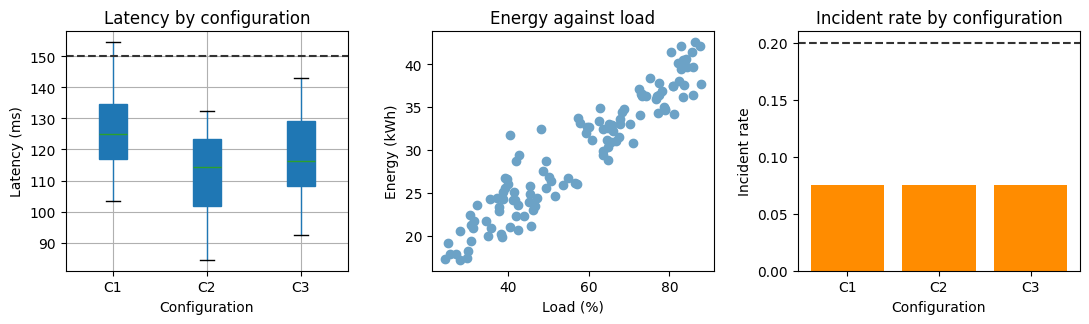

In [3]:
print(df.groupby("configuration")[["latency_ms", "energy_kwh", "incident"]].agg(["mean", "std", "size"]))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
df.boxplot(column="latency_ms", by="configuration", ax=axes[0], patch_artist=True)
axes[0].axhline(150, color="0.2", linestyle="--")
axes[0].set_xlabel("Configuration")
axes[0].set_ylabel("Latency (ms)")
axes[0].set_title("Latency by configuration")
axes[1].scatter(df["load_pct"], df["energy_kwh"], c="#6CA2C6")
axes[1].set_xlabel("Load (%)")
axes[1].set_ylabel("Energy (kWh)")
axes[1].set_title("Energy against load")
inc = df.groupby("configuration")["incident"].mean()
axes[2].bar(inc.index, inc.values, color="#FF8C00")
axes[2].axhline(0.20, color="0.2", linestyle="--")
axes[2].set_xlabel("Configuration")
axes[2].set_ylabel("Incident rate")
axes[2].set_title("Incident rate by configuration")
plt.suptitle("")
plt.tight_layout()
plt.show()


### Planned method 1 — mean latency by configuration (Chapter 9)


In [4]:
m1 = ols("latency_ms ~ C(configuration)", data=df).fit()
tbl = anova_lm(m1, typ=2)
print(tbl)
ss_b = tbl.loc["C(configuration)", "sum_sq"]
eta2 = ss_b / (ss_b + tbl.loc["Residual", "sum_sq"])
print(f"eta-squared = {eta2:.3f}")
print(pairwise_tukeyhsd(df["latency_ms"], df["configuration"], alpha=0.05))


                        sum_sq     df         F    PR(>F)
C(configuration)   3304.635047    2.0  9.900652  0.000107
Residual          19526.102152  117.0       NaN       NaN
eta-squared = 0.145


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
    C1     C2  -12.736 0.0001 -19.5935 -5.8785   True
    C1     C3  -7.8745 0.0201  -14.732  -1.017   True
    C2     C3   4.8615  0.216   -1.996  11.719  False
-----------------------------------------------------


### Planned method 2 — energy versus load (Chapter 10)


In [5]:
X = sm.add_constant(df["load_pct"])
m2 = sm.OLS(df["energy_kwh"], X).fit()
slope = m2.params["load_pct"]
ci = m2.conf_int().loc["load_pct"]
print(f"slope = {slope:.4f} kWh per percentage point")
print(f"95% CI [{ci.iloc[0]:.4f}, {ci.iloc[1]:.4f}], t = {m2.tvalues['load_pct']:.2f}, p = {m2.pvalues['load_pct']:.4g}")
print(f"R^2 = {m2.rsquared:.3f}, residual SD = {np.sqrt(m2.scale):.3f} kWh")
print("Pearson r =", pearsonr(df["load_pct"], df["energy_kwh"])[0])
pred = m2.get_prediction([1, 60])
print("at 60% load, mean and 95% mean CI / prediction interval:")
print(pred.summary_frame(alpha=0.05)[["mean", "mean_ci_lower", "mean_ci_upper", "obs_ci_lower", "obs_ci_upper"]])


slope = 0.3469 kWh per percentage point
95% CI [0.3249, 0.3689], t = 31.24, p = 6.734e-59
R^2 = 0.892, residual SD = 2.267 kWh
Pearson r = 0.9445314422408642
at 60% load, mean and 95% mean CI / prediction interval:
        mean  mean_ci_lower  mean_ci_upper  obs_ci_lower  obs_ci_upper
0  30.550174      30.136045      30.964302     26.041357      35.05899


60% load is inside the observed range. This regression describes the energy–load association in the benchmark; it does not by itself prove a causal production effect.

### Planned method 3 — incident rates by configuration (Chapter 11)


In [6]:
tab = pd.crosstab(df["configuration"], df["incident"])
tab.columns = ["no_incident", "incident"]
print(tab)
print("incident rates:\n", df.groupby("configuration")["incident"].mean())
chi2_stat, p_chi, dof, expected = chi2_contingency(tab, correction=False)
print("expected:\n", np.round(expected, 2))
print(f"chi2 = {chi2_stat:.2f}, df = {dof}, p = {p_chi:.4g}")
N = tab.to_numpy().sum()
V = np.sqrt(chi2_stat / (N * min(tab.shape[0] - 1, tab.shape[1] - 1)))
print(f"Cramér's V = {V:.3f}")


               no_incident  incident
configuration                       
C1                      37         3
C2                      37         3
C3                      37         3
incident rates:
 configuration
C1    0.075
C2    0.075
C3    0.075
Name: incident, dtype: float64
expected:
 [[37.  3.]
 [37.  3.]
 [37.  3.]]
chi2 = 0.00, df = 2, p = 1
Cramér's V = 0.000


Pause: write one sentence that uses **all three** results, not three disconnected verdicts.

## 4. Interpretation

Integrate, then recommend. A configuration with lower mean latency but a worse incident rate is not automatically the winner. A slope that relates energy to load tells operations how costly a high-load period is, whichever configuration is chosen.

The observed mean latencies are approximately 125.3 ms for C1, 112.6 ms for C2, and 117.4 ms for C3. The omnibus ANOVA detects a configuration difference, and Tukey's intervals distinguish C1 from both C2 and C3. C2 and C3 are not distinguished at the 5% level, so the sample does not establish that C2's observed 4.9 ms advantage over C3 is a population difference.

Mean energy use is approximately 28.7 kWh for C1, 31.3 kWh for C2, and 28.8 kWh for C3. The regression estimates an increase of about 0.347 kWh per percentage point of load over the benchmark range. This pooled regression describes the energy--load relationship; it does **not** estimate a configuration effect. The group energy means therefore remain descriptive evidence in the configuration decision.

Each configuration records 3 incidents in 40 runs, so the observed incident rates are all 7.5%. The chi-square statistic is zero and $p=1$. This does not prove equal production incident risks; it says that this benchmark contains no observed incident-rate difference to favour one configuration.

Taken together, C1 is difficult to recommend because its latency is higher without an observed energy or incident advantage over C3. C2 is the latency-first option, but it has the highest observed energy use. **C3 is a cautious compromise recommendation**: its mean latency is lower than C1's and not statistically distinguished from C2's, while its observed energy use is about 2.5 kWh lower than C2's. If latency has a strict operational value that outweighs energy, C2 may still be preferred. That trade-off should be made explicit rather than hidden behind three $p$-values.

These runs are a controlled benchmark, not a random sample of all production traffic. Random assignment of configurations in a benchmark can support a causal comparison **within the tested hardware and load range**. It does not automatically generalise to every customer workload. A production pilot should confirm both the latency--energy trade-off and incident performance under representative workloads.

Do not add a fourth method just to collect $p$-values. If you later split by load tertiles because a plot looked interesting, label that analysis as exploratory.

## 5. Project-planning template

Copy and complete this table for the group project. It is a planning tool, not a second analysis.

| Item | Your notes |
| --- | --- |
| Engineering objective and intended decision |  |
| Target population and observational unit |  |
| Dataset source and study design |  |
| Primary statistical question |  |
| Secondary statistical questions |  |
| Method 1: session/chapter, parameter, variables, why this method, assumptions, diagnostics, output |  |
| Method 2: session/chapter, parameter, variables, why this method, assumptions, diagnostics, output |  |
| Method 3: session/chapter, parameter, variables, why this method, assumptions, diagnostics, output |  |
| Practical threshold or decision criterion |  |
| Missing-data and unusual-observation plan |  |
| Planned versus exploratory analyses |  |
| Integrated reporting structure |  |
| Limitations and reproducibility checks |  |

## 6. Final-project readiness checklist

Use this checklist exactly. The detailed project brief will be published separately; this tutorial does not replace it.

- Deadline: **June 1**.
- Group size: **2–4 students**. Any deviation must be discussed with **R. Brooks before the final session, Session 12**.
- Workload: **25 hours per student**.
- Submission format: **one Jupyter notebook**.
- Explanations, reasoning, interpretation, and conclusions are written in **Markdown cells**; Python is in **code cells**.
- **Every code cell is executed** before submission so that output, tables, and figures are visible.
- The analysis includes at least **three statistical methods from three different sessions or textbook chapters**, excluding Chapter/Session 12.
- Every selected method answers a stated question and contributes to **one coherent engineering investigation** (not three unrelated tests in one notebook).
- The project complies with **Brooks, Chapter 12** and **Tutorial 12**.
- The project is discussed during the exam. It is **not graded separately**, but it contributes to the **overall course grade**.
- The same assessment principle applies to all **six assignments**: they are not separately graded, but form part of the overall exam basis and grade.

## 7. Common mistakes / things to notice

- Running every procedure in the course on one file (“p-hacking”).
- Introducing a new method that was not taught in Sessions 01–11.
- Reporting three $p$-values with no recommendation.
- Claiming causation from an observational convenience sample.
- Leaving code cells unexecuted in the submitted notebook.
- Using this worked example’s configurations as if they were your project topic.

**Conclusion:** For this benchmark, recommend C3 as the provisional compromise between latency and energy, while recognising that C2 is defensible when latency dominates the decision. The incident data do not distinguish the configurations, and a representative production pilot is needed before rollout. This is the standard for the project and oral exam: choose methods from the question, report magnitude and uncertainty, integrate the findings, and state what the study cannot support.
